In [ ]:
"""

"""

In [4]:
import os
import xarray as xr
from scipy import spatial

## How to select points in SWOT swath

In [79]:
ff = '/home/datawork-WW3/PROJECT/SWOT/WindWave/SWOT_L2_LR_SSH_WindWave_003_514_20230919T065618_20230919T074746_PGC0_01.nc'
# coloc_file = 'seastate_coloc_S1A_IW_SLC__1SDV_20230919T065253_20230919T065323_050393_061162_07E0-iw1_SWOT_L2_WindWave_20230919T065625_PGC0.nc'
# safe_s1_iw = 'SENTINEL1_DS:S1A_IW_SLC__1SDV_20230919T065253_20230919T065323_050393_061'
l2wav_s1_iw = '/home/datawork-cersat-public/cache/project/sarwave/data/products/experiments/slc/iw/l2/2023/262/S1A_IW_WAV__2SDV_20230919T065253_20230919T065323_050393_061162_07E0_E12.SAFE/l2-s1a-iw2-wav-dv-20230919t065254-20230919t065322-050393-061162-e12.nc'
subswath_sar = os.path.basename(l2wav_s1_iw).split('-')[2]
subswath_sar

'iw2'

In [64]:
dsswot = xr.open_dataset(ff)
dsswot["longitude"] = dsswot["longitude"].where(
    dsswot["longitude"] < 180, dsswot["longitude"] - 360
)
dsswot

<xarray.Dataset> Size: 129MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/31)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    polarization_karin                     (num_lines, num_sides) object 158kB ...
    swh_karin                              (num_lines, num_pixels) float64 5MB ...
    swh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    swh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    distance_to_coast                      (num_lines, num_pixels) float64 5MB ...
    heading_to_coast                       (num_lines, num_pixels) float64 5MB ...
    ancillary_surface_classification_flag  (num_lines, num_pixels) float32 3MB ...
    dynamic_ice_flag                       (num_lines, num_pixels) float32 3MB ...
    rain_flag                              (num_lines, num_pixels) float32 3MB ...
    rad_surface_type_flag                  (num_lines, num_sides) float32 79kB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   JPL
    source:                                        Ka-band radar interferometer
    history:                                       2024-01-25T01:37:07Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.69158878504673
    ssha_variance:                                 0.18105595174637423
    references:                                    V1.2.1
    equator_longitude:                             19.30

In [65]:
ds_iw_l2 = xr.open_dataset(l2wav_s1_iw,engine='h5netcdf',group='intraburst')
ds_iw_l2

<xarray.Dataset> Size: 185kB
Dimensions:                   (tile_line: 40, tile_sample: 18, c_sample: 2,
                               c_line: 2, pol: 2, k_gp: 4, phi_hf: 5)
Coordinates:
    line                      (tile_line, tile_sample) int16 1kB ...
    sample                    (tile_line, tile_sample) int16 1kB ...
    longitude                 (tile_line, tile_sample) float32 3kB ...
    latitude                  (tile_line, tile_sample) float32 3kB ...
  * pol                       (pol) <U2 16B 'VH' 'VV'
  * k_gp                      (k_gp) int16 8B 1 2 3 4
  * phi_hf                    (phi_hf) int16 10B 1 2 3 4 5
Dimensions without coordinates: tile_line, tile_sample, c_sample, c_line
Data variables: (12/14)
    corner_longitude          (tile_line, tile_sample, c_sample, c_line) float32 12kB ...
    corner_latitude           (tile_line, tile_sample, c_sample, c_line) float32 12kB ...
    land_flag                 (tile_line, tile_sample) bool 720B ...
    sigma0_filt               (tile_line, tile_sample, pol) float32 6kB ...
    normalized_variance_filt  (tile_line, tile_sample, pol) float32 6kB ...
    incidence                 (tile_line, tile_sample) float32 3kB ...
    ...                        ...
    hs_most_likely            (tile_line, tile_sample) float32 3kB ...
    hs_conf                   (tile_line, tile_sample) float32 3kB ...
    phs0_most_likely          (tile_line, tile_sample) float32 3kB ...
    phs0_conf                 (tile_line, tile_sample) float32 3kB ...
    t0m1_most_likely          (tile_line, tile_sample) float32 3kB ...
    t0m1_conf                 (tile_line, tile_sample) float32 3kB ...
Attributes: (12/29)
    aux_cal:                       S1A_AUX_CAL_V20190228T092500_G20210104T141...
    aux_ins:                       S1A_AUX_INS_V20190228T092500_G20211103T111...
    aux_pp1:                       S1A_AUX_PP1_V20190228T092500_G20220323T153...
    azimuth_steering_rate:         0.9798633249999998
    azimuth_time_interval:         0.002055556299999998
    comment:                       denoised digital number, read at full reso...
    ...                            ...
    safe:                          S1A_IW_SLC__1SDV_20230919T065253_20230919T...
    short_name:                    SENTINEL1_DS:S1A_IW_SLC__1SDV_20230919T065...
    squeezed_dimensions:           2tau
    start_date:                    2023-09-19 06:52:54.139808
    stop_date:                     2023-09-19 06:53:22.080985
    swath:                         IW

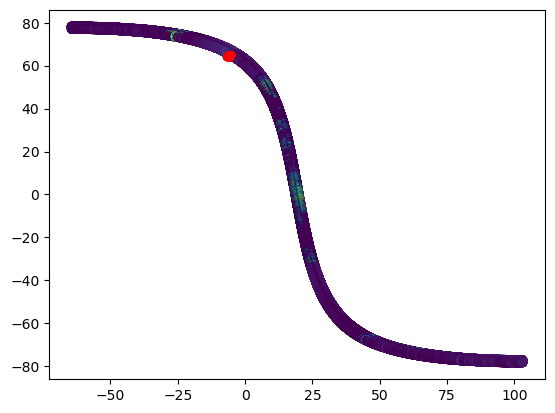

In [66]:
#dsswot['swh_karin'].plot()
from matplotlib import pyplot as plt
plt.scatter(dsswot['longitude'].values.ravel(),dsswot['latitude'].values.ravel(),c=dsswot['swh_karin'].values.ravel())
plt.plot(ds_iw_l2['longitude'].values.ravel(),ds_iw_l2['latitude'].values.ravel(),'r.')

In [71]:
subswot = dsswot.isel({'num_lines':slice(1000,1200)})
subswot

<xarray.Dataset> Size: 3MB
Dimensions:                                (num_lines: 200, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 110kB ...
    longitude                              (num_lines, num_pixels) float64 110kB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/31)
    time                                   (num_lines) datetime64[ns] 2kB ...
    time_tai                               (num_lines) datetime64[ns] 2kB ...
    polarization_karin                     (num_lines, num_sides) object 3kB ...
    swh_karin                              (num_lines, num_pixels) float64 110kB ...
    swh_karin_qual                         (num_lines, num_pixels) float64 110kB ...
    swh_karin_uncert                       (num_lines, num_pixels) float64 110kB ...
    ...                                     ...
    distance_to_coast                      (num_lines, num_pixels) float64 110kB ...
    heading_to_coast                       (num_lines, num_pixels) float64 110kB ...
    ancillary_surface_classification_flag  (num_lines, num_pixels) float32 55kB ...
    dynamic_ice_flag                       (num_lines, num_pixels) float32 55kB ...
    rain_flag                              (num_lines, num_pixels) float32 55kB ...
    rad_surface_type_flag                  (num_lines, num_sides) float32 2kB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   JPL
    source:                                        Ka-band radar interferometer
    history:                                       2024-01-25T01:37:07Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.69158878504673
    ssha_variance:                                 0.18105595174637423
    references:                                    V1.2.1
    equator_longitude:                             19.30

In [74]:
import s1swotcolocs
import numpy as np
import s1swotcolocs.seastate_colocs_s1_swot
from importlib import reload
reload(s1swotcolocs.seastate_colocs_s1_swot)
treeswot = s1swotcolocs.seastate_colocs_s1_swot.get_swot_tree(subswot)
treeswot

In [75]:
onetile_ds = ds_iw_l2.isel({'tile_line':8,'tile_sample':4})
lontile = onetile_ds['longitude'].values
lattile = onetile_ds['latitude'].values
onetile_ds
lontile,lattile

(array(-5.4145584, dtype=float32), array(64.98457, dtype=float32))

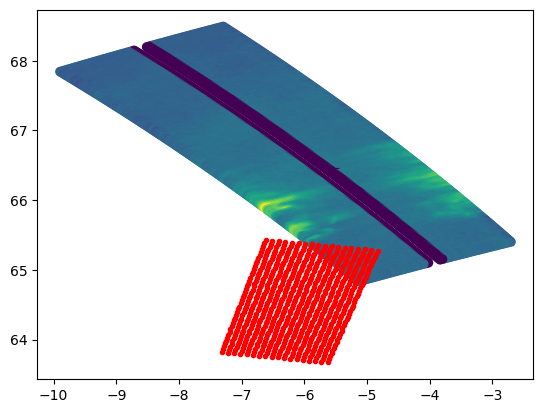

In [72]:
plt.plot(ds_iw_l2['longitude'].values.ravel(),ds_iw_l2['latitude'].values.ravel(),'r.')
plt.scatter(subswot['longitude'].values.ravel(),subswot['latitude'].values.ravel(),c=subswot['swh_karin'].values.ravel())

In [85]:
radius_coloc = 0.05

print(lontile)
neighbors = treeswot.query_ball_point([lontile, lattile], r=radius_coloc)
print(neighbors)
dstclosest,closest_index = treeswot.query([lontile, lattile], k=1)
lineclosest,pixelclosets = np.unravel_index(closest_index,subswot['longitude'].shape)
print('closest_index',closest_index,(lineclosest,pixelclosets))
swot_closest_ds = subswot.isel(num_lines=lineclosest, num_pixels=pixelclosets)
indices = []
condensated_swot = xr.Dataset()
for oneneighbor in neighbors:
    index_original_shape_swot_num_lines, index_original_shape_swot_num_pixels = np.unravel_index(oneneighbor,
                                                                                              subswot['longitude'].shape)
    idxtmp = (int(index_original_shape_swot_num_lines), int(index_original_shape_swot_num_pixels))
    # print(idxtmp)
    indices.append(idxtmp)
# print(indices)
subset = [subswot.isel(num_lines=i, num_pixels=j) for i, j in indices]
len(subset)

-5.4145584
[12971, 13109, 13040, 12970, 12901, 13178, 13108, 13039]
closest_index 13109 (np.int64(189), np.int64(68))


8

In [86]:
subset

[<xarray.Dataset> Size: 244B
 Dimensions:                                (num_sides: 2)
 Coordinates:
     latitude                               float64 8B 65.0
     longitude                              float64 8B -5.454
 Dimensions without coordinates: num_sides
 Data variables: (12/31)
     time                                   datetime64[ns] 8B ...
     time_tai                               datetime64[ns] 8B ...
     polarization_karin                     (num_sides) object 16B ...
     swh_karin                              float64 8B nan
     swh_karin_qual                         float64 8B ...
     swh_karin_uncert                       float64 8B ...
     ...                                     ...
     distance_to_coast                      float64 8B ...
     heading_to_coast                       float64 8B ...
     ancillary_surface_classification_flag  float32 4B ...
     dynamic_ice_flag                       float32 4B ...
     rain_flag                             

In [83]:
indices

[(187, 68),
 (189, 68),
 (188, 68),
 (187, 67),
 (186, 67),
 (190, 68),
 (189, 67),
 (188, 67)]

/tmp/pbs.3887196.datarmor0/ipykernel_2464374/2504616913.py:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


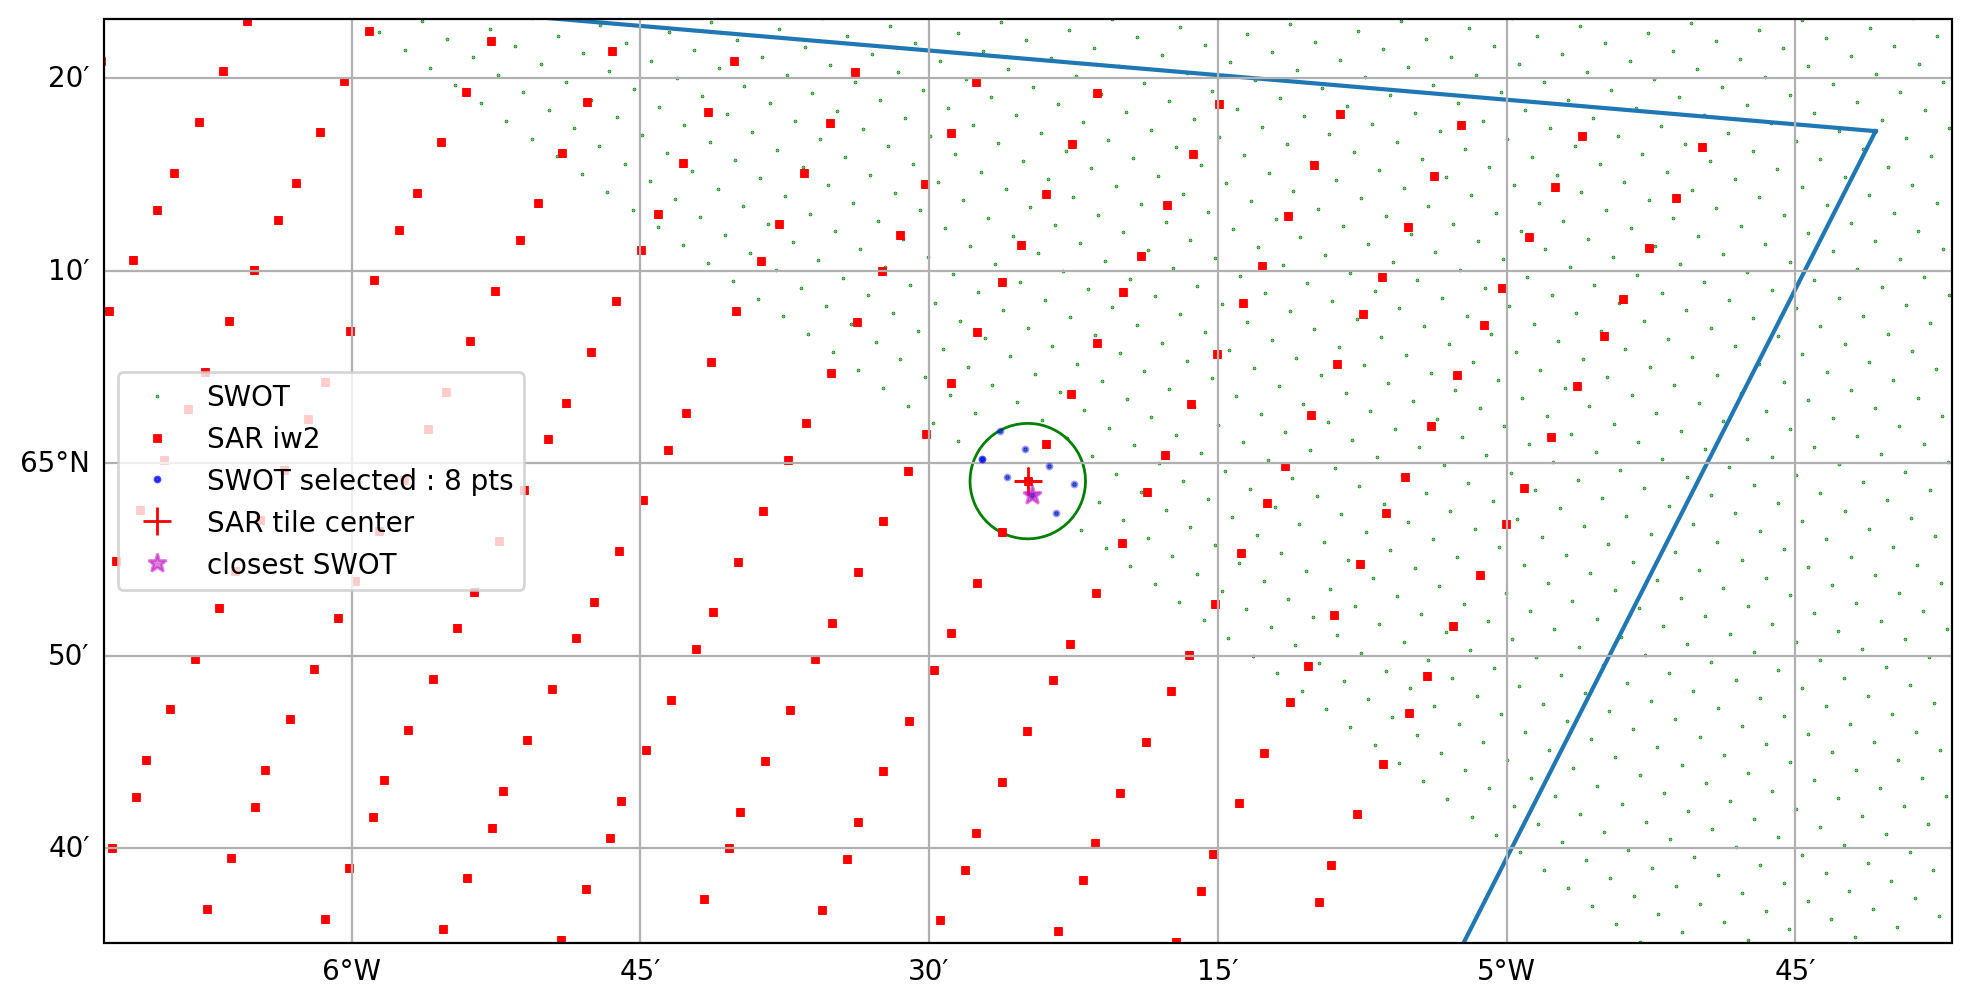

In [95]:
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt
from shapely import wkt
from shapely.geometry import Point
fig = plt.figure(dpi=200,figsize=(18,6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) #false_easting=100,false_northing=100000)




petitswot = dsswot.isel({'num_lines':slice(0,-1,1)})
plt.plot(petitswot['longitude'].values.ravel(),petitswot['latitude'].values.ravel(),'g.',label='SWOT',ms=0.6)
petitsar = plt.plot(ds_iw_l2['longitude'].values.ravel(),ds_iw_l2['latitude'].values.ravel(),'rs',label='SAR '+subswath_sar,ms=2)
plt.plot(*wkt.loads(ds_iw_l2.attrs['footprint']).exterior.xy)
# plt.ylim(60,80)
# plt.xlim(10,25)
delta_bound_lon = 0.4*2 #deg
delta_bound_lat = 0.2*2
plt.ylim(lattile-delta_bound_lat,lattile+delta_bound_lat)
plt.xlim(lontile-delta_bound_lon,lontile+delta_bound_lon)

# plt.title('SAR index : %s'%indexes_sar)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.right_labels = False  # Disable labels on the right
gl.top_labels = False    # Optional: disable labels on the top too

for ux,uu in enumerate(subset):
    if ux==0:
        plt.plot(uu['longitude'],uu['latitude'],'bo',ms=1.8,alpha=0.7,label='SWOT selected : %i pts'%len(subset))
    else:
        plt.plot(uu['longitude'],uu['latitude'],'bo',ms=1.8,alpha=0.4)
plt.plot(lontile,lattile,'r+',label='SAR tile center',ms=10)

# add the circle of coloc
circle = Point(lontile, lattile).buffer(radius_coloc)

# Wrap into GeoDataFrame for plotting
gdf = gpd.GeoDataFrame(geometry=[circle], crs=ccrs.PlateCarree()) # "EPSG:4326"

# add closest SWOT (for understanding)
ax.plot(swot_closest_ds['longitude'],swot_closest_ds['latitude'],'m*',label='closest SWOT',alpha=0.5,ms=7)

# Plot
ax = gdf.plot(facecolor='none', edgecolor='green',ax=ax,label='%f° coloc radius, centered on SAR tile')
plt.legend()

# same illustration for points close to nadir 

In [96]:
import s1swotcolocs
import numpy as np
import s1swotcolocs.seastate_colocs_s1_swot
from importlib import reload
reload(s1swotcolocs.seastate_colocs_s1_swot)
from  s1swotcolocs.seastate_colocs_s1_swot import lines_to_keep_in_swot_swath 
print(lines_to_keep_in_swot_swath)
dsswotl2_closenadir = dsswot.isel({'num_pixels':lines_to_keep_in_swot_swath}) # selection validated in notebook
dsswotl2_closenadir

[28, 29, 30, 39, 40, 41]


<xarray.Dataset> Size: 12MB
Dimensions:                                (num_lines: 9866, num_pixels: 6,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 474kB ...
    longitude                              (num_lines, num_pixels) float64 474kB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/31)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    polarization_karin                     (num_lines, num_sides) object 158kB ...
    swh_karin                              (num_lines, num_pixels) float64 474kB ...
    swh_karin_qual                         (num_lines, num_pixels) float64 474kB ...
    swh_karin_uncert                       (num_lines, num_pixels) float64 474kB ...
    ...                                     ...
    distance_to_coast                      (num_lines, num_pixels) float64 474kB ...
    heading_to_coast                       (num_lines, num_pixels) float64 474kB ...
    ancillary_surface_classification_flag  (num_lines, num_pixels) float32 237kB ...
    dynamic_ice_flag                       (num_lines, num_pixels) float32 237kB ...
    rain_flag                              (num_lines, num_pixels) float32 237kB ...
    rad_surface_type_flag                  (num_lines, num_sides) float32 79kB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   JPL
    source:                                        Ka-band radar interferometer
    history:                                       2024-01-25T01:37:07Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.69158878504673
    ssha_variance:                                 0.18105595174637423
    references:                                    V1.2.1
    equator_longitude:                             19.30

In [126]:
subswot = dsswotl2_closenadir.isel({'num_lines':slice(1000,1500)})
treeswot = s1swotcolocs.seastate_colocs_s1_swot.get_swot_tree(subswot)
treeswot
subswot

<xarray.Dataset> Size: 592kB
Dimensions:                                (num_lines: 500, num_pixels: 6,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 24kB ...
    longitude                              (num_lines, num_pixels) float64 24kB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/31)
    time                                   (num_lines) datetime64[ns] 4kB ...
    time_tai                               (num_lines) datetime64[ns] 4kB ...
    polarization_karin                     (num_lines, num_sides) object 8kB ...
    swh_karin                              (num_lines, num_pixels) float64 24kB ...
    swh_karin_qual                         (num_lines, num_pixels) float64 24kB ...
    swh_karin_uncert                       (num_lines, num_pixels) float64 24kB ...
    ...                                     ...
    distance_to_coast                      (num_lines, num_pixels) float64 24kB ...
    heading_to_coast                       (num_lines, num_pixels) float64 24kB ...
    ancillary_surface_classification_flag  (num_lines, num_pixels) float32 12kB ...
    dynamic_ice_flag                       (num_lines, num_pixels) float32 12kB ...
    rain_flag                              (num_lines, num_pixels) float32 12kB ...
    rad_surface_type_flag                  (num_lines, num_sides) float32 4kB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   JPL
    source:                                        Ka-band radar interferometer
    history:                                       2024-01-25T01:37:07Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       68.69158878504673
    ssha_variance:                                 0.18105595174637423
    references:                                    V1.2.1
    equator_longitude:                             19.30

In [127]:
l2wav_s1_iw = '/home/datawork-cersat-public/cache/project/sarwave/data/products/experiments/slc/iw/l2/2023/262/S1A_IW_WAV__2SDV_20230919T065253_20230919T065323_050393_061162_07E0_E12.SAFE/l2-s1a-iw1-wav-dv-20230919t065253-20230919t065321-050393-061162-e12.nc'
subswath_sar = os.path.basename(l2wav_s1_iw).split('-')[2]
ds_iw_l2 = xr.open_dataset(l2wav_s1_iw,engine='h5netcdf',group='intraburst')

In [128]:
onetile_ds = ds_iw_l2.isel({'tile_line':2,'tile_sample':12})
lontile = onetile_ds['longitude'].values
lattile = onetile_ds['latitude'].values
onetile_ds
lontile,lattile

(array(-4.355478, dtype=float32), array(65.19661, dtype=float32))

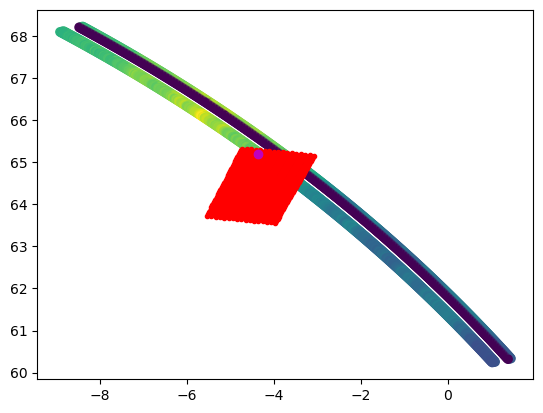

In [129]:
plt.plot(ds_iw_l2['longitude'].values.ravel(),ds_iw_l2['latitude'].values.ravel(),'r.')
plt.scatter(subswot['longitude'].values.ravel(),subswot['latitude'].values.ravel(),c=subswot['swh_karin'].values.ravel())
plt.plot(lontile,lattile,'mo')

(array(-4.2033787, dtype=float32), array(65.27409, dtype=float32))

In [130]:
radius_coloc = 0.08

print(lontile)
neighbors = treeswot.query_ball_point([lontile, lattile], r=radius_coloc)
print(neighbors)
dstclosest,closest_index = treeswot.query([lontile, lattile], k=1)
lineclosest,pixelclosets = np.unravel_index(closest_index,subswot['longitude'].shape)
print('closest_index',closest_index,(lineclosest,pixelclosets))
swot_closest_ds = subswot.isel(num_lines=lineclosest, num_pixels=pixelclosets)
indices = []
condensated_swot = xr.Dataset()
for oneneighbor in neighbors:
    index_original_shape_swot_num_lines, index_original_shape_swot_num_pixels = np.unravel_index(oneneighbor,
                                                                                              subswot['longitude'].shape)
    idxtmp = (int(index_original_shape_swot_num_lines), int(index_original_shape_swot_num_pixels))
    # print(idxtmp)
    indices.append(idxtmp)
# print(indices)
subset = [subswot.isel(num_lines=i, num_pixels=j) for i, j in indices]
len(subset)

-4.355478
[1139, 1132, 1125, 1145, 1162, 1163, 1169, 1131, 1138, 1151, 1137, 1157, 1144, 1150, 1143, 1156, 1149, 1155]
closest_index 1144 (np.int64(190), np.int64(4))


18

/tmp/pbs.3887196.datarmor0/ipykernel_2464374/2337785617.py:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


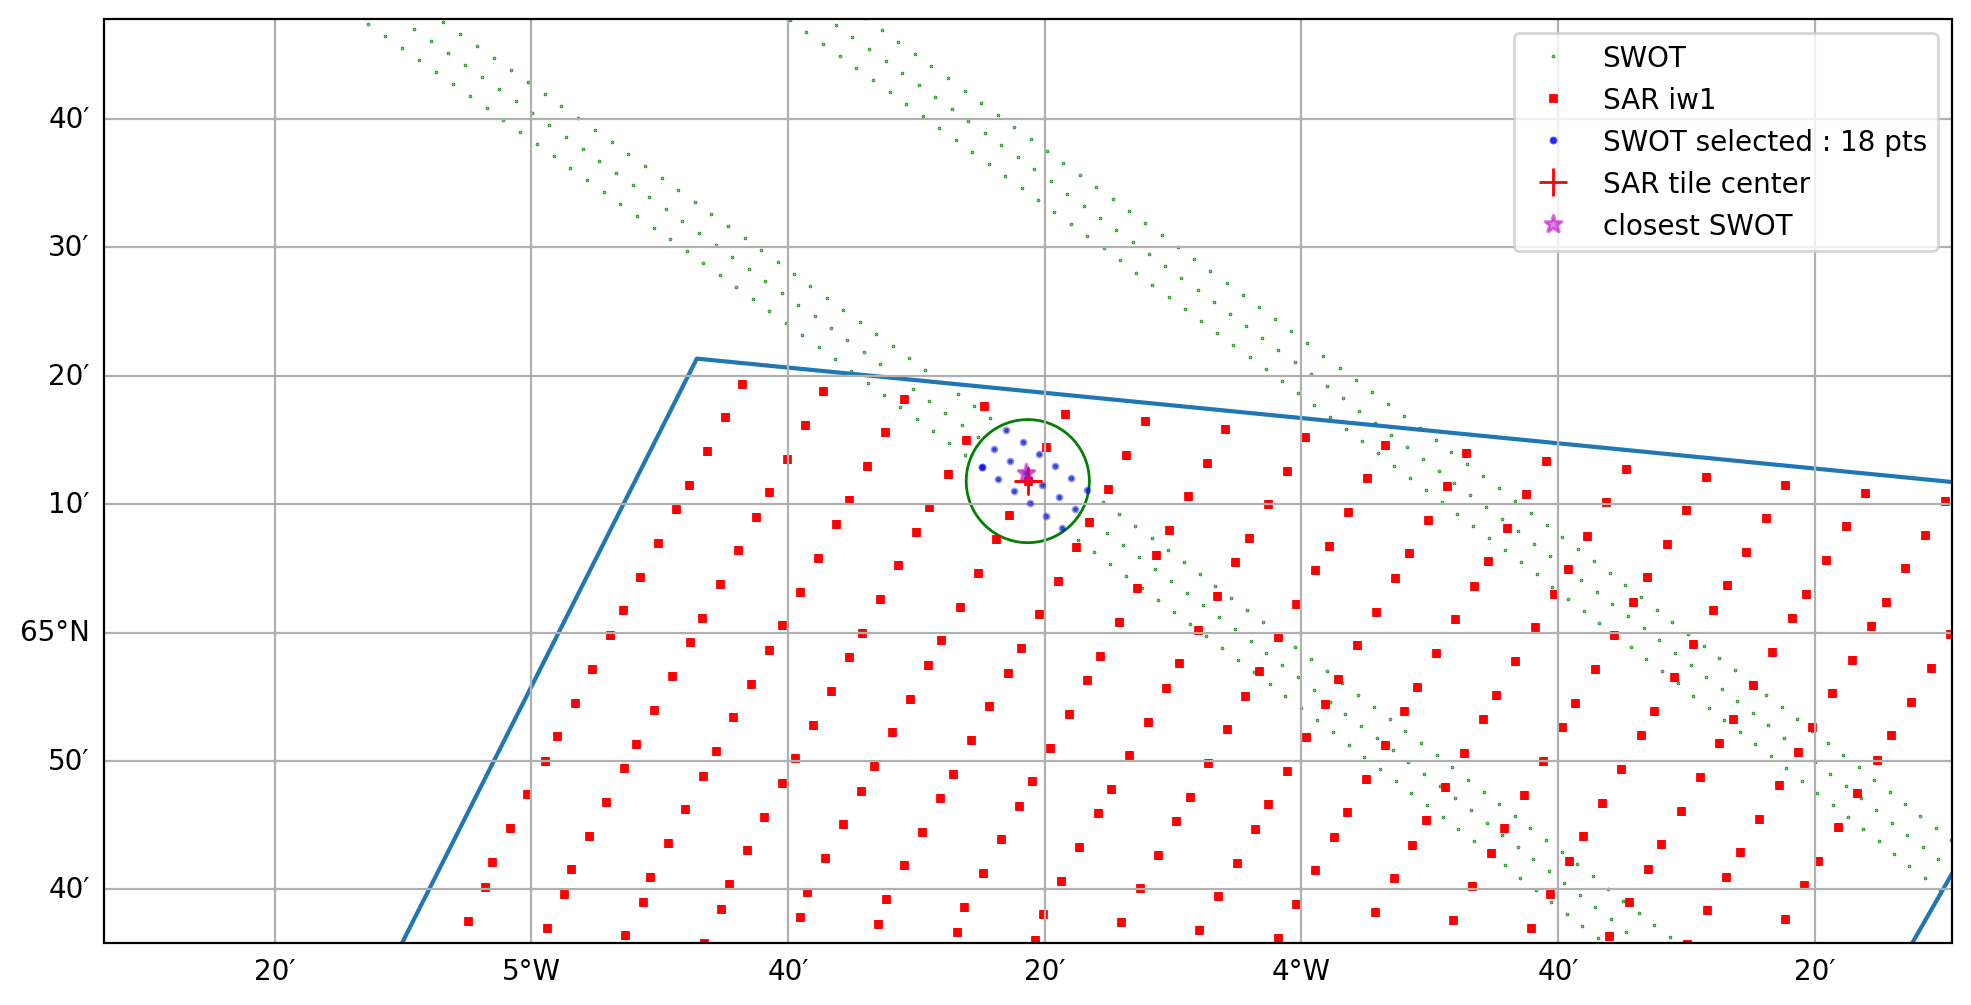

In [131]:
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt
from shapely import wkt
from shapely.geometry import Point
fig = plt.figure(dpi=200,figsize=(18,6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) #false_easting=100,false_northing=100000)




# petitswot = dsswot.isel({'num_lines':slice(0,-1,1)})
plt.plot(subswot['longitude'].values.ravel(),subswot['latitude'].values.ravel(),'g.',label='SWOT',ms=0.6)
petitsar = plt.plot(ds_iw_l2['longitude'].values.ravel(),ds_iw_l2['latitude'].values.ravel(),'rs',label='SAR '+subswath_sar,ms=2)
plt.plot(*wkt.loads(ds_iw_l2.attrs['footprint']).exterior.xy)
# plt.ylim(60,80)
# plt.xlim(10,25)
delta_bound_lon = 0.4*3 #deg
delta_bound_lat = 0.2*3
plt.ylim(lattile-delta_bound_lat,lattile+delta_bound_lat)
plt.xlim(lontile-delta_bound_lon,lontile+delta_bound_lon)

# plt.title('SAR index : %s'%indexes_sar)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.right_labels = False  # Disable labels on the right
gl.top_labels = False    # Optional: disable labels on the top too

for ux,uu in enumerate(subset):
    if ux==0:
        plt.plot(uu['longitude'],uu['latitude'],'bo',ms=1.8,alpha=0.7,label='SWOT selected : %i pts'%len(subset))
    else:
        plt.plot(uu['longitude'],uu['latitude'],'bo',ms=1.8,alpha=0.4)
plt.plot(lontile,lattile,'r+',label='SAR tile center',ms=10)

# add the circle of coloc
circle = Point(lontile, lattile).buffer(radius_coloc)

# Wrap into GeoDataFrame for plotting
gdf = gpd.GeoDataFrame(geometry=[circle], crs=ccrs.PlateCarree()) # "EPSG:4326"

# add closest SWOT (for understanding)
ax.plot(swot_closest_ds['longitude'],swot_closest_ds['latitude'],'m*',label='closest SWOT',alpha=0.5,ms=7)

# Plot
ax = gdf.plot(facecolor='none', edgecolor='green',ax=ax,label='%f° coloc radius, centered on SAR tile')
plt.legend()